In [11]:
import math
import os
import pickle
import random
from collections import deque, namedtuple
from itertools import pairwise
from math import prod
from typing import Callable
import pandas as pd
import torch
from IPython.core.pylabtools import figsize
from gymnasium.spaces.utils import *
from pandas import DataFrame
from torch.nn import *

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps' if torch.mps.is_available() else
    'cpu'
)

Experience = namedtuple('Experience', ('state', 'action', 'reward', 'next_state', 'not_done'))

class ReplayBuffer:
    def __init__(self, capacity: int):
        self._mem = []
        self._buffer = deque(self._mem, maxlen=capacity)

    def push(self, *args):
        self._buffer.append(Experience(*args))

    def sample(self, batch_size):
        samp = random.sample(self._buffer, batch_size)
        # samp.append(self._buffer[-1])
        return samp

    def __len__(self):
        return len(self._buffer)

class DQN(Sequential):
    def __init__(self, hidden, input_shape, output_shape, ):
        super().__init__()
        self.hidden = hidden
        self.input_shape = input_shape
        self.output_shape = output_shape
        n_inputs = prod(input_shape)
        n_outputs = prod(output_shape)

        self.add_module("Flatten", Flatten())
        self.add_module("Linear_input", Linear(n_inputs, hidden[0]))
        # self.add_module('BatchNorm_input', BatchNorm1d(hidden[0]))
        self.add_module("ReLU_input", ReLU(inplace=True))

        for idx, (i, o) in enumerate(pairwise(hidden)):
            self.add_module(f'Linear_{idx}', Linear(i, o))
            # self.add_module(f'BatchNorm_{idx}', BatchNorm1d(o))
            self.add_module(f'RElU_{idx}', ReLU(inplace=True))

        self.add_module(f'Linear_output', Linear(hidden[-1], n_outputs))
        # self.add_module('BatchNorm_output', BatchNorm1d(n_outputs))
        # self.add_module("Output", ReLU(inplace=True))
        self.add_module("Unflatten", Unflatten(1, output_shape))

HyperParams = namedtuple('HyperParams', (
    'mem_limit',
    'episodes',
    'step_count',
    'batch_size',
    'epsilon_start',
    'epsilon_end',
    'epsilon_decay',
    'gamma',
    'learning_rate',
    'target_network_update_freq'
))

class DqnTrainer:
    def __init__(self, *, env: gym.Env, hyperparams: HyperParams, dqn: DQN, stop_callback: Callable[[list, list], bool] | None = None):
        super().__init__()

        self.env = env
        self.hyper = hyperparams
        self.memory = ReplayBuffer(hyperparams.mem_limit)
        self.state = None
        self.info = None
        self.steps_done = 0
        self.episodes_done = 0
        self.epsilon = 0
        self.policy_net = dqn.to(device)
        self.target_net = pickle.loads(pickle.dumps(self.policy_net)).to(device)
        self.loss = MSELoss()
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), hyperparams.learning_rate)
        self.stop_callback = stop_callback if stop_callback is not None else lambda a, b, c: False
        self.reset()

    def reset(self):
        obs, info = self.env.reset()
        self.state = torch.from_numpy(obs).unsqueeze(0).to(device)
        self.steps_done = 0
        # self.episodes_done = 0
        # self.epsilon = self.hyper.epsilon_start

    def _epsilon_greedy_action_select(self):
        self.policy_net.eval()
        # epsilon = max(self.hyper.epsilon_start * (1.0 - self.hyper.epsilon_decay) ** self.steps_done, self.hyper.epsilon_end)
        self.steps_done += 1

        if random.uniform(0, 1) <= self.epsilon:
            retval =  torch.tensor([[env.action_space.sample()]]).to(device=device)
            return retval
        else:
            with torch.no_grad():
                res = self.policy_net(self.state)
                res = res.max(1).indices.view(1, 1)
                return res

    def _optimize(self):
        self.target_net.eval()
        if len(self.memory) < self.hyper.batch_size:
            return
        self.policy_net.train()

        exp = self.memory.sample(self.hyper.batch_size)
        batch = Experience(*zip(*exp))

        state_batch = torch.cat(batch.state).to(device=device)
        action_batch = torch.cat(batch.action).to(device=device)
        reward_batch = torch.cat(batch.reward).to(device=device)
        not_done_batch = torch.tensor(batch.not_done, device=device)
        next_state_batch = torch.cat(batch.next_state).to(device=device)

        state_action_values = self.policy_net(state_batch).gather(1, action_batch).squeeze()

        with torch.no_grad():
            chosen_actions = self.policy_net(next_state_batch).max(1).indices.unsqueeze(1)
            next_state_values = self.target_net(next_state_batch).gather(1, chosen_actions).squeeze() * not_done_batch
        expected_state_action_values = (next_state_values * self.hyper.gamma) + reward_batch
        loss = self.loss(state_action_values, expected_state_action_values)

        self.optimizer.zero_grad()
        loss.backward()

        # torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 50)
        self.optimizer.step()

    def train(self, model_dir, model_name):
        ep_durations = []
        rewards = []
        it_cnt = 0
        self.epsilon = self.hyper.epsilon_start
        model_prefix = os.path.join(model_dir, model_name)
        best_reward = -math.inf

        for episode in range(self.hyper.episodes):
            ep_rewards = []
            c_reward = 0
            self.reset()
            step = 0
            for step in range(self.hyper.step_count):
                new_action = self._epsilon_greedy_action_select()
                observation, reward, terminated, truncated, info = self.env.step(new_action.item())
                done = terminated or truncated
                c_reward += reward
                reward = torch.tensor([reward], device=device, dtype=torch.float32)

                next_state = torch.from_numpy(observation).unsqueeze(0).to(device=device)

                self.memory.push(self.state, new_action, reward, next_state, int(not done))
                self.state = next_state

                self._optimize()
                
                it_cnt += 1
                if it_cnt >= self.hyper.target_network_update_freq:
                    self.target_net.load_state_dict(self.policy_net.state_dict())
                    it_cnt = 0
                ep_rewards.append(reward)

                if terminated:
                    break

            if c_reward > best_reward:
                torch.save(self.policy_net, f'{model_prefix}.best.pth')
                best_reward = c_reward
                
            rewards.append(c_reward)
            # epsilons.append(self.epsilon)
            ep_durations.append(step + 1)
            self.epsilon = max(self.hyper.epsilon_end, self.epsilon * (1.0 - self.hyper.epsilon_decay))

            if self.stop_callback(rewards, ep_durations):
                break

        return DataFrame({
            "episode_length": ep_durations,
            "episode_reward": rewards,
            # "epsilons": epsilons
        })

from pathlib import Path
from imageio import mimsave

def play(env, policy_net, export_path: Union[Path, str], max_steps = 1000):
    os.makedirs(Path(export_path).parent, exist_ok=True)
    network.eval()
    env.reset()
    frames = []

    state, info = env.reset()
    frames.append(env.render())
    for step in range(max_steps):
        next_action = policy_net(torch.tensor(state).to(device=device).unsqueeze(0)).argmax(1).item()
        state, reward, terminated, truncated, info = env.step(next_action)
        frames.append(env.render())
        if truncated or terminated:
            break
    mimsave(export_path, frames, duration=30)

In [12]:
history_dir = 'history/V4.2'
model_dir = 'models/V4.2'
history_file = os.path.join(history_dir, 'lunar_lander.csv')
model_file = os.path.join(model_dir, 'lunar_lander.pth')
os.makedirs(history_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

In [13]:

from torchinfo import summary

hyperparams = HyperParams(
    20000,
    1000,
    600,
    128,
    1.0,
    0.01,
    0.05,
    0.99,
    10e-4,
    200
)


env = gym.make('LunarLander-v3')
network = DQN([128], env.observation_space.shape, [4]).to(device=device)
print(summary(network, input_size=(1, *env.observation_space.shape)))
reward_buf = []
reward_queue = deque(reward_buf, 10)

def stop(rewards, _):
    if len(rewards) < 10:
        return False
    return np.mean(rewards[-10:]) >= 250

trainer = DqnTrainer(env=env, hyperparams=hyperparams, dqn=network, stop_callback=stop)
history_2 = trainer.train(model_dir, 'lunar_lander')
history_2.to_csv(history_file)
torch.save(network, model_file)


Layer (type:depth-idx)                   Output Shape              Param #
DQN                                      [1, 4]                    --
├─Flatten: 1-1                           [1, 8]                    --
├─Linear: 1-2                            [1, 128]                  1,152
├─ReLU: 1-3                              [1, 128]                  --
├─Linear: 1-4                            [1, 4]                    516
├─Unflatten: 1-5                         [1, 4]                    --
Total params: 1,668
Trainable params: 1,668
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01


In [14]:
network = torch.load(os.path.join(model_dir, f'lunar_lander.best.pth'), weights_only=False)
env = gym.make('LunarLander-v3', render_mode='rgb_array')
play(env, network, "gifs/V4.2/lunar_lander.gif")

<img src="gifs/V4.1/lunar_lander.gif"/>

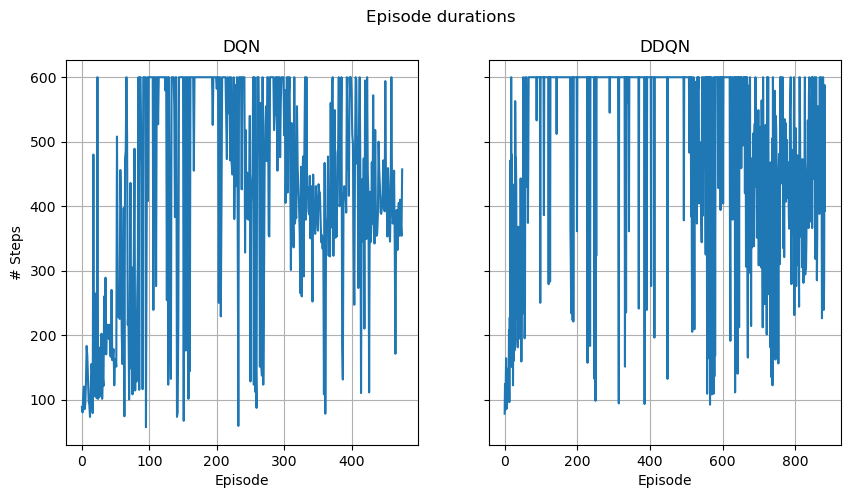

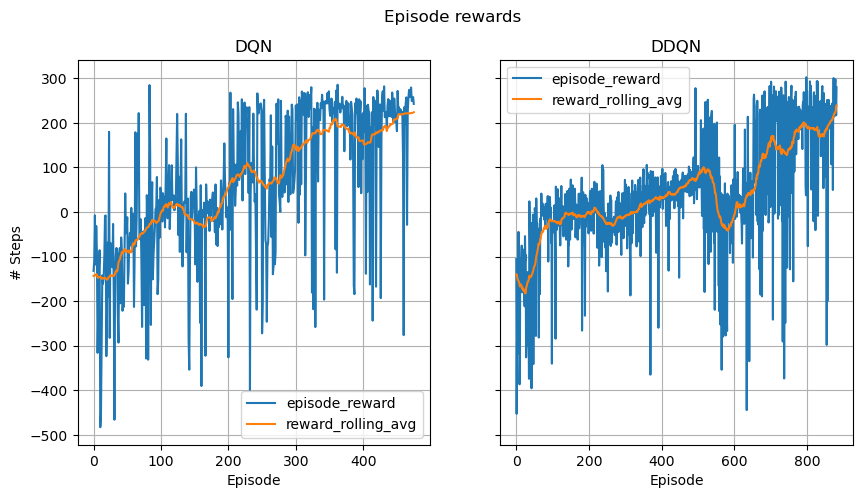

In [19]:
import matplotlib.pyplot as plt

history_2 = pd.read_csv(history_file)
history_1 = pd.read_csv('history/V4.1/lunar_lander.csv')

r = history_2['episode_reward'].to_numpy()
r = np.convolve(np.pad(r, pad_width=(25, 25), mode='edge'), np.full((51,), 1/51), mode="valid")
history_2['reward_rolling_avg'] = r
r = history_1['episode_reward'].to_numpy()
r = np.convolve(np.pad(r, pad_width=(25, 25), mode='edge'), np.full((51,), 1/51), mode="valid")
history_1['reward_rolling_avg'] = r

fig, axes = plt.subplots(1, 2, sharey=True, figsize=[10, 5])
fig.suptitle("Episode durations")

plot = history_2['episode_length'].plot(ax = axes[1])
plot.set_title('DDQN')
plot.set_ylabel("# Steps")
plot.set_xlabel("Episode")
plot.grid(True)

plot = history_1['episode_length'].plot(ax = axes[0])
plot.set_title("DQN")
plot.set_ylabel("# Steps")
plot.set_xlabel("Episode")
plot.grid(True)
plt.show()

fig, axes = plt.subplots(1, 2, sharey=True, figsize=[10, 5])
fig.suptitle("Episode rewards")

plot = history_1[['episode_reward', 'reward_rolling_avg']].plot(ax = axes[0])
plot.set_title('DQN')
plot.set_ylabel("# Steps")
plot.set_xlabel("Episode")
plot.grid(True)
plot = history_2[['episode_reward', 'reward_rolling_avg']].plot(ax = axes[1])
plot.set_title('DDQN')
plot.set_ylabel('Reward')
plot.set_xlabel('Episode')
plot.grid(True)
plt.show()

# plot = history['epsilons'].plot()
# plt.show()